# Rolling Linear Regression

- We introduced pairs trading based on cointegration in [Chapter 9](../09_time_series_models).
- An important implementation step involved the estimation of the hedge ratio to determine the relative size of offsetting positions.
- In this notebook, we will explore how to compute this ratio using rolling Bayesian linear regression.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline
from pathlib import Path

import numpy as np
import arviz as az
import pymc as pm

from sklearn.preprocessing import scale

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# model_path = Path('models')
sns.set_style("whitegrid")

## Simple Linear Regression Demo

### Artificial Data

In [4]:
size = 200
true_intercept = 1
true_slope = 2

x = np.linspace(0, 1, size)
true_regression_line = true_intercept + true_slope * x
y = true_regression_line + np.random.normal(scale=0.5, size=size)

### Model Definition

In [5]:
with pm.Model() as linear_regression:  # model specification
    # Define priors
    sd = pm.HalfCauchy("sigma", beta=10, initval=1)  # unique name for each variable
    intercept = pm.Normal("intercept", mu=0, sigma=20)
    slope = pm.Normal("slope", mu=0, sigma=20)

    # Define likelihood
    likelihood = pm.Normal("y", mu=intercept + slope * x, sigma=sd, observed=y)

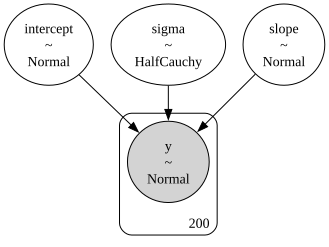

In [6]:
pm.model_to_graphviz(linear_regression)

### HMC Inference

In [7]:
with linear_regression:
    # Inference
    trace = pm.sample(
        draws=2500,  # draw 2500 samples from posterior using NUTS sampling
        tune=1000,
        chains=4,
        cores=1,
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, intercept, slope]


Sampling 4 chains for 1_000 tune and 2_500 draw iterations (4_000 + 10_000 draws total) took 5 seconds.


### Posterior Parameter Distributions

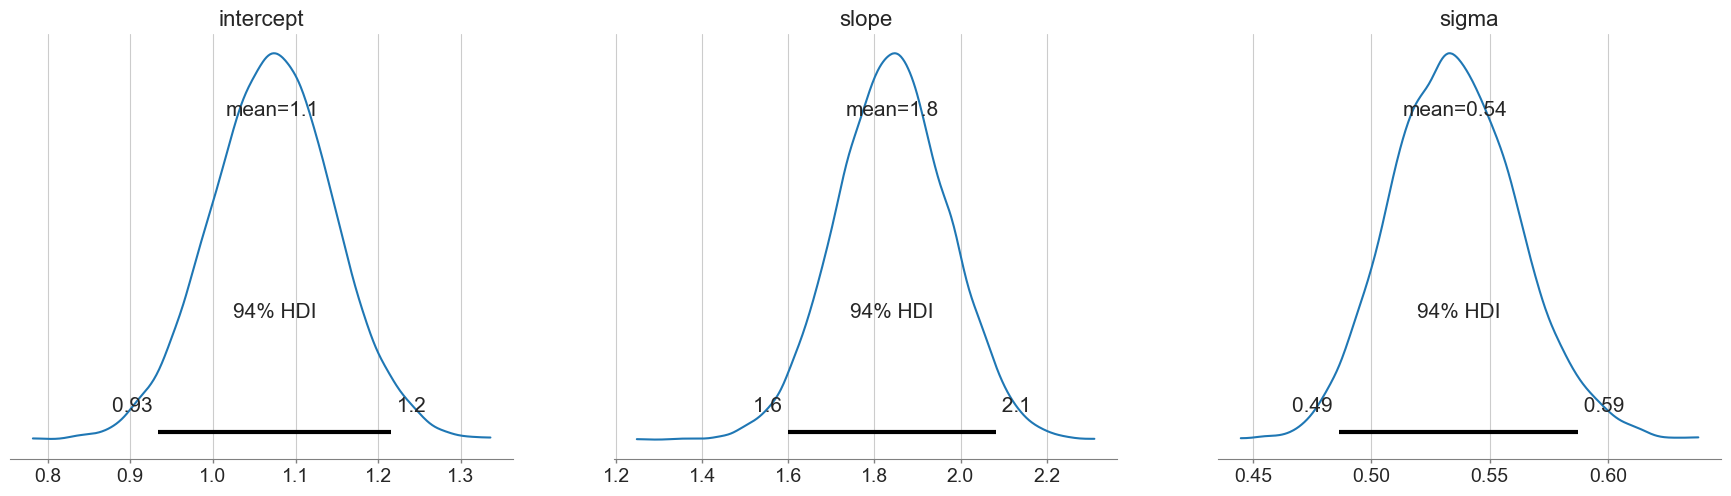

In [8]:
az.plot_posterior(trace);

## Linear Regression for Pairs Trading
Based on Thomas Wiecki's [rolling regression](https://docs.pymc.io/notebooks/GLM-rolling-regression.html) example.

In [9]:
prices = yf.download("GFI GLD", period="max").dropna().loc[:, "Close"]

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


In [10]:
returns = prices.pct_change().dropna()

In [11]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5170 entries, 2004-11-18 to 2025-06-06
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GFI     5170 non-null   float64
 1   GLD     5170 non-null   float64
dtypes: float64(2)
memory usage: 121.2 KB


In [12]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5169 entries, 2004-11-19 to 2025-06-06
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GFI     5169 non-null   float64
 1   GLD     5169 non-null   float64
dtypes: float64(2)
memory usage: 121.1 KB


In [13]:
prices_normed = prices.apply(scale)

Plotting the prices over time suggests a strong correlation. However, the correlation seems to change over time.

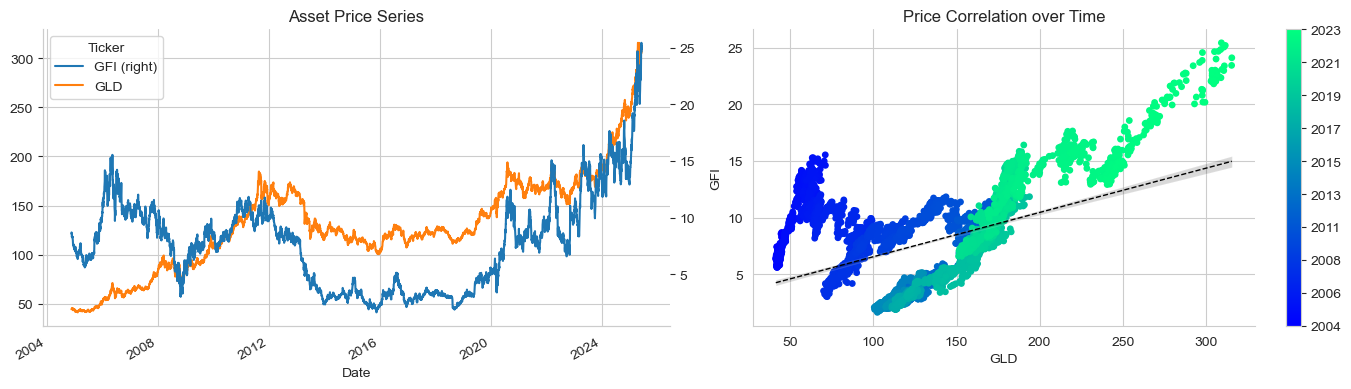

In [14]:
fig, axes = plt.subplots(figsize=(14, 4), ncols=2)

prices.plot(secondary_y="GFI", ax=axes[0])
axes[0].set_title("Asset Price Series")
points = axes[1].scatter(
    prices.GLD, prices.GFI, c=np.linspace(0.1, 1, len(prices)), s=15, cmap="winter"
)
axes[1].set_title("Price Correlation over Time")
cbar = plt.colorbar(points, ax=axes[1])
cbar.ax.set_yticklabels([str(p.year) for p in returns[:: len(returns) // 10].index])
sns.regplot(
    x="GLD",
    y="GFI",
    data=prices,
    scatter=False,
    color="k",
    line_kws={"lw": 1, "ls": "--"},
    ax=axes[1],
)
sns.despine()
fig.tight_layout();

A naive approach would be to estimate a linear model and ignore the time domain.

In [15]:
with pm.Model() as model_reg:
    # Define priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    slope = pm.Normal("slope", mu=0, sigma=10)
    sigma = pm.HalfCauchy("sigma", beta=1)

    # Expected value of outcome
    mu = intercept + slope * prices["GLD"]

    # Likelihood (sampling distribution) of observations
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=prices["GFI"])

    # Sample from the posterior
    trace_reg = pm.sample(draws=5000, tune=1000, chains=4, cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, slope, sigma]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 17 seconds.


The posterior predictive plot shows how bad the fit is.

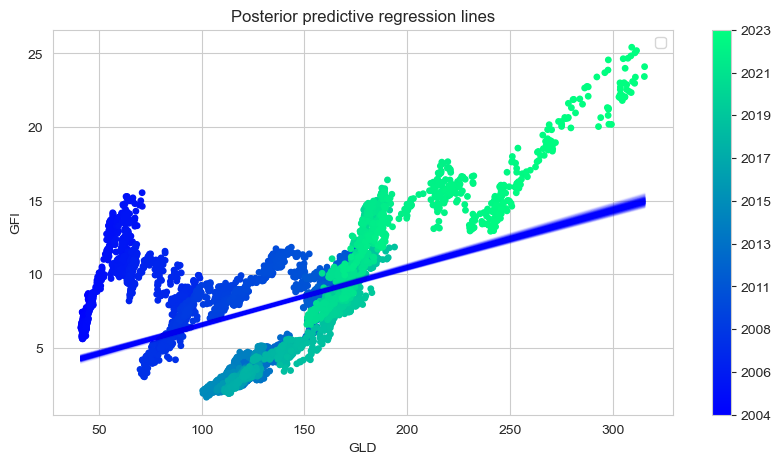

In [16]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(
    111, xlabel="GLD", ylabel="GFI", title="Posterior predictive regression lines"
)
points = ax.scatter(
    prices.GLD, prices.GFI, c=np.linspace(0.1, 1, len(prices)), s=15, cmap="winter"
)

# Generate x values for prediction
x_vals = np.linspace(prices.GLD.min(), prices.GLD.max(), 100)

# Draw 250 random samples from the posterior
posterior_samples = trace_reg.posterior.stack(samples=("chain", "draw"))
idx = np.random.choice(posterior_samples.samples.size, 250, replace=False)

for i in idx:
    intercept = posterior_samples["intercept"].values.flatten()[i]
    slope = posterior_samples["slope"].values.flatten()[i]
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, color="blue", alpha=0.05)

cb = plt.colorbar(points)
cb.ax.set_yticklabels([str(p.year) for p in prices[:: len(prices) // 10].index])
ax.legend(loc=0);

## Rolling regression

Next, we will build an improved model that will allow for changes in the regression coefficients over time. Specifically, we will assume that intercept and slope follow a random-walk through time.

$$\begin{align*} 
\alpha_t &\sim \mathcal{N}(\alpha_{t-1}, \sigma_\alpha^2)\\
\beta_t & \sim \mathcal{N}(\beta_{t-1}, \sigma_\beta^2)
\end{align*}$$

First, lets define the hyper-priors for $\sigma_\alpha^2$ and $\sigma_\beta^2$. This parameter can be interpreted as the volatility in the regression coefficients.

In [19]:
with pm.Model() as model_randomwalk:
    sigma_alpha = pm.Exponential("sigma_alpha", 1.0)
    alpha = pm.GaussianRandomWalk("alpha", sigma=sigma_alpha, shape=len(prices))

    sigma_beta = pm.Exponential("sigma_beta", 1.0)
    beta = pm.GaussianRandomWalk("beta", sigma=sigma_beta, shape=len(prices))
    # Define regression
    regression = alpha + beta * prices_normed.GLD

    # Assume prices are normally distributed
    # Get mean from regression.
    sd = pm.HalfNormal("sd", sigma=0.1)
    likelihood = pm.Normal("y", mu=regression, sigma=sd, observed=prices_normed.GFI)

    trace_rw = pm.sample(
        tune=2000,
        draws=200,
        chains=4,
        cores=1,
        target_accept=0.9,
        progressbar=True,
        nuts_sampler="nutpie",
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2200,0,0.02,1023
,2200,0,0.02,1023
,2200,0,0.02,1023
,2200,0,0.02,1023


In [20]:
az.summary(trace_rw)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_alpha_log__,-3.772,0.033,-3.837,-3.716,0.011,0.005,9.0,46.0,1.42
alpha[0],1.277,0.920,0.309,2.940,0.446,0.225,5.0,17.0,2.79
alpha[1],1.278,0.918,0.286,2.915,0.445,0.225,5.0,17.0,2.81
alpha[2],1.277,0.917,0.302,2.923,0.445,0.225,5.0,19.0,2.79
alpha[3],1.273,0.917,0.302,2.919,0.445,0.225,5.0,18.0,2.82
...,...,...,...,...,...,...,...,...,...
beta[5169],1.339,0.078,1.192,1.472,0.033,0.013,6.0,14.0,1.91
sd_log__,-5.104,0.182,-5.545,-4.880,0.085,0.058,5.0,12.0,2.41
sigma_alpha,0.023,0.001,0.022,0.024,0.000,0.000,9.0,46.0,1.42
sigma_beta,0.051,0.001,0.049,0.054,0.000,0.000,14.0,263.0,1.22


## Analysis of results

As can be seen below, $\alpha$, the intercept, changes over time.

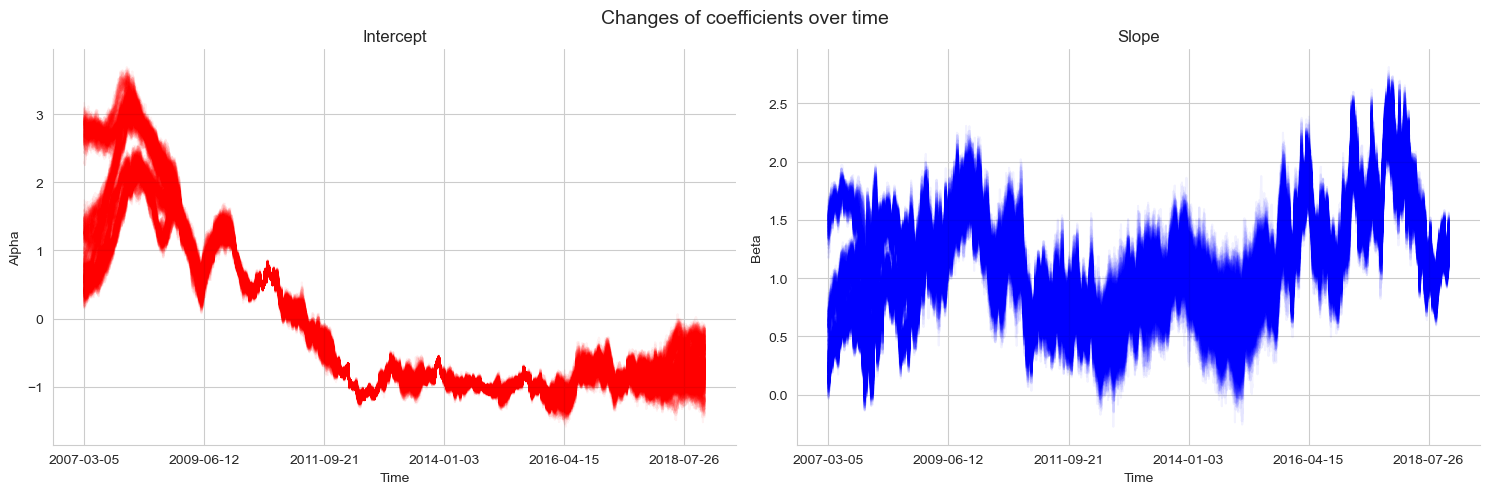

In [21]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=2, sharex=True)

# Stack chains and draws for plotting
alpha_samples = (
    trace_rw.posterior["alpha"].stack(sample=("chain", "draw")).values
)  # shape: (len(prices), n_samples)
beta_samples = (
    trace_rw.posterior["beta"].stack(sample=("chain", "draw")).values
)  # shape: (len(prices), n_samples)

axes[0].plot(alpha_samples, "r", alpha=0.05)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Alpha")
axes[0].set_title("Intercept")
axes[0].set_xticklabels([str(p.date()) for p in prices[:: len(prices) // 9].index])

axes[1].plot(beta_samples, "b", alpha=0.05)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Beta")
axes[1].set_title("Slope")

fig.suptitle("Changes of coefficients over time", fontsize=14)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=0.9)

The posterior predictive plot shows that we capture the change in regression over time much better. Note that we should have used returns instead of prices. The model would still work the same, but the visualisations would not be quite as clear.

In [22]:
x = np.linspace(prices_normed.GLD.min(), prices_normed.GLD.max())

dates = [str(p.year) for p in prices[:: len(prices) // 9].index]

colors = np.linspace(0.1, 1, len(prices))
colors_sc = np.linspace(0.1, 1, alpha_samples.shape[1] // 10)

cmap = plt.get_cmap("winter")

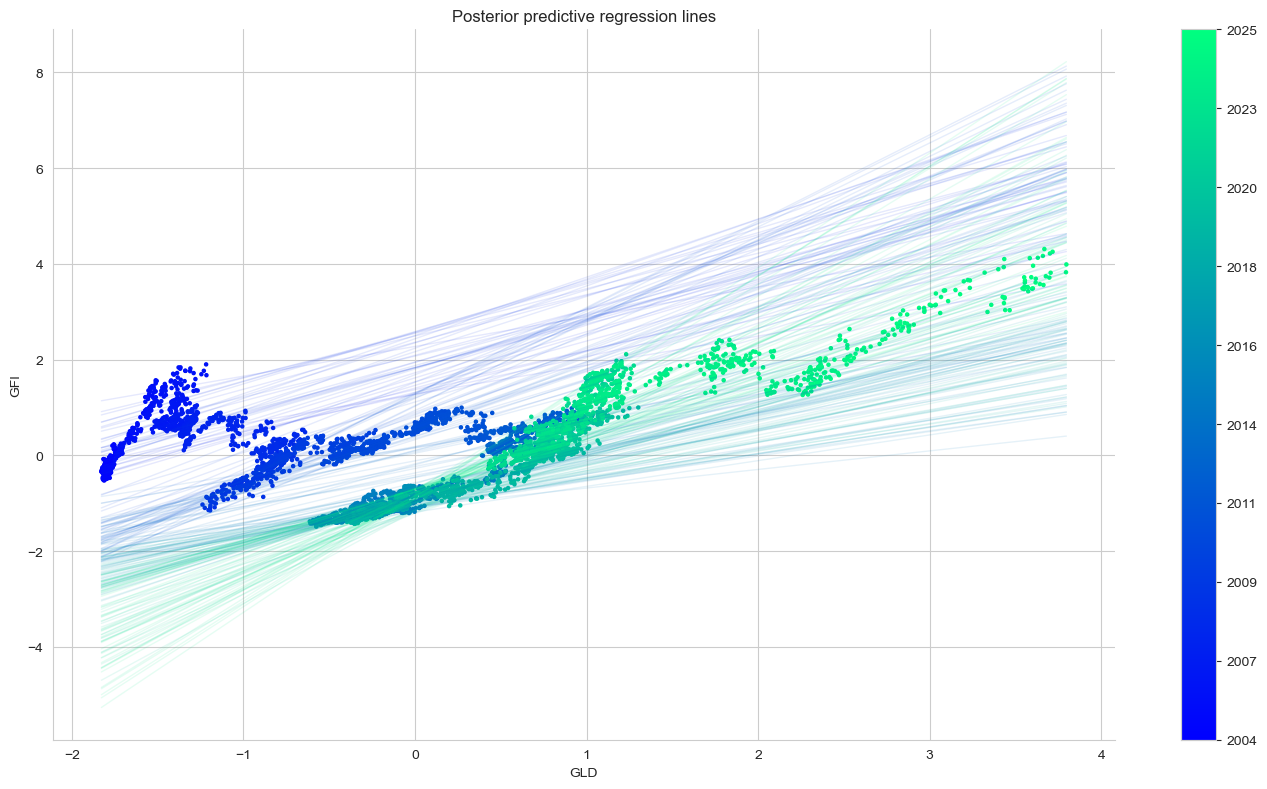

In [31]:
fig, ax = plt.subplots(figsize=(14, 8))

# 1. Get the mean of alpha and beta across all chains and draws for each time step.
#    This will result in 1D xarray.DataArray objects, indexed by 'time_idx'.
alpha_means_per_time = trace_rw.posterior["alpha"].mean(dim=["chain", "draw"])
beta_means_per_time = trace_rw.posterior["beta"].mean(dim=["chain", "draw"])

# 2. Determine which time steps to plot (every 25th time step, as in your original logic).
#    This assumes 'time_idx' is the name of your time dimension in the InferenceData object.
#    Adjust 'time_idx' if your dimension has a different name.
plotting_interval = 25
num_time_steps = alpha_means_per_time.sizes["alpha_dim_0"]
plot_time_indices = np.arange(0, num_time_steps, plotting_interval)

# 3. Generate colors for the plotted lines. The number of colors should match
#    the number of lines we are actually plotting.
colors_for_plotted_lines = np.linspace(0.1, 1, len(plot_time_indices))

# 4. Iterate through the selected time indices and plot the mean regression line for each.
for i, time_idx in enumerate(plot_time_indices):
    # Access the mean alpha and beta for the current time_idx using .isel()
    # .item() is used to convert the 0-dimensional xarray DataArray to a scalar.
    mean_alpha = alpha_means_per_time.isel(alpha_dim_0=time_idx).item()
    mean_beta = beta_means_per_time.isel(beta_dim_0=time_idx).item()

    # Plot the regression line with the desired opacity and line width
    ax.plot(
        x,
        mean_alpha + mean_beta * x,
        alpha=0.1,  # You can increase this (e.g., to .1 or higher) for better visibility
        lw=1.0,  # You can increase this (e.g., to 1.0 or higher) for thicker lines
        c=cmap(colors_for_plotted_lines[i]),
    )

# ... (your existing code for scatter plot, colorbar, labels, title, etc.) ...

points = ax.scatter(prices_normed.GLD, prices_normed.GFI, c=colors, s=5, cmap=cmap)

cbar = plt.colorbar(points)
cbar.ax.set_yticklabels(dates)
ax.set_xlabel("GLD")
ax.set_ylabel("GFI")
ax.set_title("Posterior predictive regression lines")
sns.despine()
fig.tight_layout();